# Experience Study

The following site (https://www.soa.org/resources/tables-calcs-tools/experience-study-tool/) has an excel workbook that provides few examples of calculating exposure (annual, distributed, exact). This notebook uses the same example data to show the calculation.

In [1]:
import os
import sys

os.chdir("../../")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import polars as pl

In [2]:
from morai.experience import charters, credibility, experience, tables

In [3]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

In [4]:
pd.options.display.float_format = "{:,.2f}".format

# Exposures

There are 3 different methods for calculating exposure ("annual", "distributed", "exact") and 3 different assumptions for distribution of deaths ("balducci hypothesis", "uniform distribution", "constant"). When the exposure method matches the distribution the rates are constant for fractional periods. The rates are similar but not the same when reviewing a full year of exposure regardless of method.

- **annual:** balducci hypothesis (BH) - calculates an initial rate (qx)
- **distributed:** uniform distribution of deaths (UDD) - calculates an initial rate (qx)
- **exact:** constant mortality rate (CMR) - calculates a central rate (mx)

A central rate (mx) can be used to approximate initial rate (qx) using the average force of mortality (ux).
- mx ≈ ux
- qx = 1 - exp(-ux)
- ux = -log(1-qx)

## Annual Exposure

In section 4.3.1 of the report, it shows the exposure calculation for 6 different type of policies shown below.

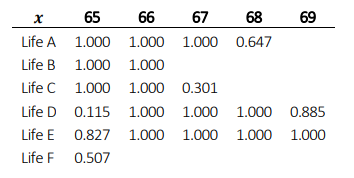

In [5]:
soa_data = pd.read_csv("notebooks/files/sample_experience_data_soa.csv")

In [6]:
soa_data

,id,gender,smoker,issue_date,amount,termination_date,termination_reason,notes
0,1,F,NS,5/10/2010,"100,000",NaN,NaN,NaN
1,2,M,NS,9/27/2010,"100,000",2/16/2012,D,NaN
2,3,M,NS,7/3/2010,"100,000",10/21/2012,L,NaN
3,4,M,NS,2/12/2009,"100,000",NaN,NaN,NaN
4,5,M,NS,10/30/2009,"100,000",12/27/2013,D,NaN
5,6,M,NS,7/5/2009,"100,000",3/17/2010,D,NaN


In [7]:
study_df = experience.create_study(
    df=soa_data,
    bos="1/1/2010",
    eos="12/31/2014",
    study_decrement="D",
    exposure_method="annual",
    calendar_exposure=False,
)

 2026-08-16 09:48:49 | morai.experience.experience | INFO     | formatting df... 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | study periods: `2010-01-01` to `2014-12-31` 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | study frequency: `annually` 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | shape before: (6, 8), shape_after: (38, 13) 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | getting exposures... 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | exposure method: `annual` - rate type: `qx` 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | calendar exposure: `False` 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | study decrement: `D` 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | getting actuals... 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | total actuals: 3 


In [8]:
study_df.pivot_table(
    index="id",
    columns="policy_dur",
    values="exposure_cnt",
    aggfunc="sum",
)

policy_dur,1,2,3,4,5,6
id,,,,,,
1,1.00,1.00,1.00,1.00,0.65,NaN
2,1.00,1.00,NaN,NaN,NaN,NaN
3,1.00,1.00,0.30,NaN,NaN,NaN
4,0.12,1.00,1.00,1.00,1.00,0.88
5,0.83,1.00,1.00,1.00,1.00,NaN
6,0.51,NaN,NaN,NaN,NaN,NaN


## Compare Methods

Reviewing the annual rates by death distribution (section 9.1), assuming fractional-like exposure.
  - Constant mortality rate (CMR) it is expected to have a straight line. A uniform distribution of deaths (UDD) it is expected to be a lower mortality rate in the beginning and then increase over time.

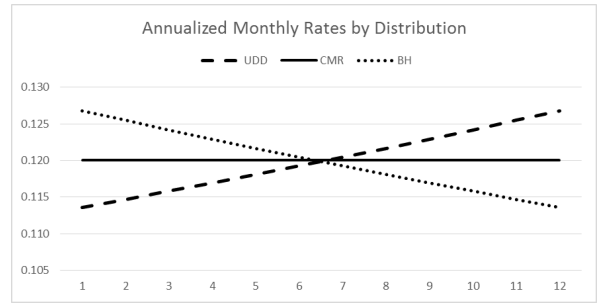

Reviewing the annual rates by exposure method (section 9.1.4) assuming a constant mortality rate. This is what is shown in code example as well.
  - We see the CMR be constant slope, but the UDD starts high and then is lower at the end. 

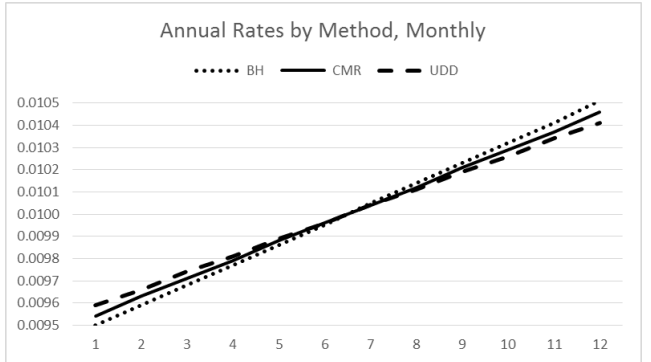

In [9]:
soa_compare_data = pd.read_csv(
    "notebooks/files/sample_experience_data_compare_dist.csv"
)

In [10]:
# calculate exposures 3 different ways
study_df = experience.create_study(
    df=soa_compare_data,
    bos="2023-01-01",
    eos="2023-12-31",
    study_frequency="monthly",
    exposure_method="distributed",
    study_decrement="D",
    calendar_exposure=True,
    get_exposures=False,
)
study_df["exposure_annual"] = experience.calc_exposures(
    study_df=study_df,
    study_decrement="D",
    exposure_method="annual",
    calendar_exposure=True,
)
study_df["exposure_dist"] = experience.calc_exposures(
    study_df=study_df,
    study_decrement="D",
    exposure_method="distributed",
    calendar_exposure=True,
)
study_df["exposure_exact"] = experience.calc_exposures(
    study_df=study_df,
    study_decrement="D",
    exposure_method="exact",
    calendar_exposure=True,
)

 2026-08-16 09:48:49 | morai.experience.experience | INFO     | formatting df... 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | study periods: `2023-01-01` to `2023-12-31` 
 2026-08-16 09:48:49 | morai.experience.experience | INFO     | study frequency: `monthly` 
 2026-08-16 09:48:50 | morai.experience.experience | INFO     | shape before: (10000, 4), shape_after: (120000, 9) 
 2026-08-16 09:48:50 | morai.experience.experience | INFO     | getting actuals... 
 2026-08-16 09:48:50 | morai.experience.experience | INFO     | total actuals: 1,207 
 2026-08-16 09:48:50 | morai.experience.experience | INFO     | getting exposures... 
 2026-08-16 09:48:50 | morai.experience.experience | INFO     | exposure method: `annual` - rate type: `qx` 
 2026-08-16 09:48:50 | morai.experience.experience | INFO     | calendar exposure: `True` 
 2026-08-16 09:48:50 | morai.experience.experience | INFO     | study decrement: `D` 
 2026-08-16 09:48:50 | morai.experience.experience | INFO  

In [11]:
# group by month and then create qx
compare_df = (
    study_df.groupby("eos_date")[
        ["actual_cnt", "exposure_annual", "exposure_dist", "exposure_exact"]
    ]
    .sum()
    .reset_index()
)
compare_df["qx_annual"] = compare_df["actual_cnt"] / compare_df["exposure_annual"]
compare_df["qx_dist"] = compare_df["actual_cnt"] / compare_df["exposure_dist"]
compare_df["ux_exact"] = compare_df["actual_cnt"] / compare_df["exposure_exact"]
compare_df["qx_exact"] = 1 - np.exp(-compare_df["ux_exact"])

# create total row
total_df = compare_df.copy()
total = total_df.sum(numeric_only=True)
total["qx_annual"] = total["actual_cnt"] / total["exposure_annual"]
total["qx_dist"] = total["actual_cnt"] / total["exposure_dist"]
total["ux_exact"] = total["actual_cnt"] / total["exposure_exact"]
total["qx_exact"] = 1 - np.exp(-total["ux_exact"])
total["eos_date"] = "total"
total_df = pd.concat([total_df, total.to_frame().T], ignore_index=True)

pd.options.display.float_format = "{:,.4f}".format
total_df

,eos_date,actual_cnt,exposure_annual,exposure_dist,exposure_exact,qx_annual,qx_dist,ux_exact,qx_exact
0,2023-01-31 00:00:00,108,948.1425,849.3151,849.3151,0.1139,0.1272,0.1272,0.1194
1,2023-02-28 00:00:00,97,840.1589,767.1233,758.8384,0.1155,0.1264,0.1278,0.1200
2,2023-03-31 00:00:00,106,911.7671,849.3151,831.9041,0.1163,0.1248,0.1274,0.1196
3,2023-04-30 00:00:00,102,864.8219,821.9178,796.3562,0.1179,0.1241,0.1281,0.1202
4,2023-05-31 00:00:00,104,875.2137,849.3151,814.2384,0.1188,0.1225,0.1277,0.1199
5,2023-06-30 00:00:00,100,829.8356,821.9178,779.4247,0.1205,0.1217,0.1283,0.1204
6,2023-07-31 00:00:00,102,839.6685,849.3151,796.9123,0.1215,0.1201,0.1280,0.1201
7,2023-08-31 00:00:00,101,822.0082,849.3151,788.2493,0.1229,0.1189,0.1281,0.1203
8,2023-09-30 00:00:00,97,778.9699,821.9178,754.5205,0.1245,0.1180,0.1286,0.1206
9,2023-10-31 00:00:00,99,787.9781,849.3151,771.4329,0.1256,0.1166,0.1283,0.1204


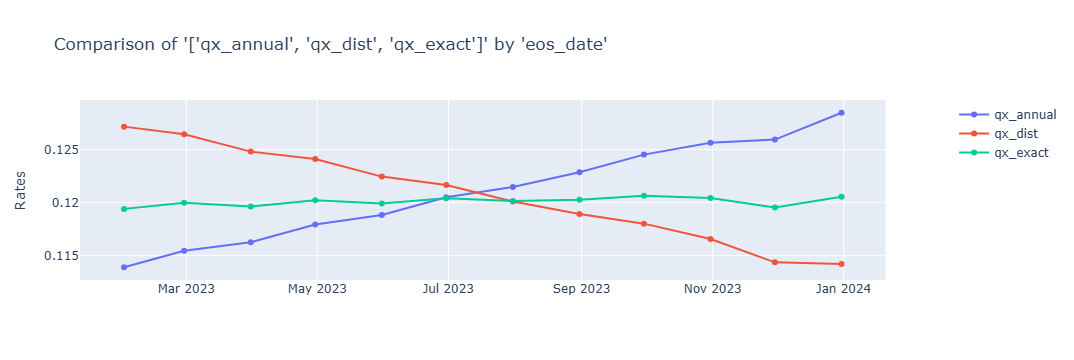

In [12]:
pd.options.display.float_format = "{:,.2f}".format
charters.compare_rates(
    df=compare_df[compare_df["eos_date"] != "Total"],
    x_axis="eos_date",
    rates=["qx_annual", "qx_dist", "qx_exact"],
)

# Experience Study

Create an experience study from a sample dataset of 1,000 policies that have terminations from 2010 through 2020

## Seriatim

In [13]:
experience_data = pd.read_excel(
    "notebooks/files/sample_experience_data.xlsx", sheet_name="data"
)

### Exposures

Creating the experience study and calculating the exposures using the `annual` method

In [14]:
study_df = experience.create_study(
    df=experience_data,
    bos="1/1/2010",
    eos="12/31/2020",
    study_decrement="L",
    exposure_method="annual",
    calendar_exposure=False,
    study_frequency="annually",
    amount_col="amount",
)

 2026-08-16 09:48:57 | morai.experience.experience | INFO     | formatting df... 
 2026-08-16 09:48:57 | morai.experience.experience | INFO     | study periods: `2010-01-01` to `2020-12-31` 
 2026-08-16 09:48:57 | morai.experience.experience | INFO     | study frequency: `annually` 
 2026-08-16 09:48:58 | morai.experience.experience | INFO     | shape before: (10000, 7), shape_after: (125062, 12) 
 2026-08-16 09:48:58 | morai.experience.experience | INFO     | getting exposures... 
 2026-08-16 09:48:58 | morai.experience.experience | INFO     | exposure method: `annual` - rate type: `qx` 
 2026-08-16 09:48:58 | morai.experience.experience | INFO     | calendar exposure: `False` 
 2026-08-16 09:48:58 | morai.experience.experience | INFO     | study decrement: `L` 
 2026-08-16 09:48:58 | morai.experience.experience | INFO     | getting actuals... 
 2026-08-16 09:48:58 | morai.experience.experience | INFO     | total actuals: 8,917 


### Expected

Adding in the expected lapse rates to the study to calculate the expected count and amount

In [15]:
study_df = tables.map_rates(
    df=study_df,
    rate="basic_lapse",
)

 2026-08-16 09:48:58 | morai.experience.tables | INFO     | mapping rate: 'qx_basic_lapse' with format: 'csv' 
 2026-08-16 09:48:58 | morai.experience.tables | INFO     | the mapped rates are based on the following keys: ['policy_dur'] 


In [16]:
study_df["expected_base_cnt"] = study_df["qx_basic_lapse"] * study_df["exposure_cnt"]
study_df["expected_base_amt"] = study_df["expected_base_cnt"] * study_df["amount"]

### Variance

#### Process Variance

Calculate the process variance using the `binomial` distribution

In [17]:
study_df["variance_base_cnt"] = experience.calc_variance(
    seriatim_df=study_df,
    rate_col="qx_basic_lapse",
    exposure_col="exposure_cnt",
    amount_col=None,
    distribution="binomial",
)
study_df["variance_base_amt"] = experience.calc_variance(
    seriatim_df=study_df,
    rate_col="qx_basic_lapse",
    exposure_col="exposure_cnt",
    amount_col="amount",
    distribution="binomial",
)

 2026-08-16 09:49:10 | morai.experience.experience | INFO     | calculated process_variance using distribution: `binomial`, dispersion: `1.0` 
 2026-08-16 09:49:10 | morai.experience.experience | INFO     | calculated process_variance using distribution: `binomial`, dispersion: `1.0` 


#### Component Variance

In [18]:
sigma_dict_subtraction = experience.estimate_sigma(
    df=study_df,
    assumption="base",
    suffix="cnt",
    group_col="policy_dur",
    method="subtraction",
)

 2026-08-16 09:49:16 | morai.experience.experience | INFO     | estimated sigma using: `subtraction` 
 2026-08-16 09:49:16 | morai.experience.experience | INFO     | estimated sigma: (`0.0289`) 
 2026-08-16 09:49:16 | morai.experience.experience | INFO     | `95%` confidence intervals [`0.0142`, `0.0583`] 


In [19]:
sigma_duration_cnt = experience.estimate_sigma(
    df=study_df,
    assumption="base",
    suffix="cnt",
    group_col="policy_dur",
    method="phi",
)

 2026-08-16 09:49:22 | morai.experience.experience | INFO     | estimated sigma using: `phi` 
 2026-08-16 09:49:22 | morai.experience.experience | INFO     | estimated sigma: (`0.0313`) 
 2026-08-16 09:49:22 | morai.experience.experience | INFO     | `95%` confidence intervals [`0.0181`, `0.0601`] 


In [20]:
variance_df = experience.calc_component_variance(
    seriatim_df=study_df,
    assumption="base",
    suffix="cnt",
    groupby_cols=["policy_dur"],
    component_dict={
        "ae_total": sigma_duration_cnt,
        "components": {"duration": sigma_duration_cnt},
    },
)

 2026-08-16 09:49:30 | morai.experience.experience | INFO     | calculated component_variance, grouped by: `['policy_dur']` 
 2026-08-16 09:49:30 | morai.experience.experience | INFO     | shock_components: `['duration']` 
 2026-08-16 09:49:30 | morai.experience.experience | INFO     | scaling variance by A/E total: `0.99` 


In [21]:
variance_df

,actual_cnt,expected_base_cnt,variance_process_cnt,variance_component_duration_cnt,variance_total_cnt,sd_process_cnt,sd_total_cnt
policy_dur,,,,,,,
1,1016,"1,000.00",900.00,948.89,"1,835.98",30.00,42.85
2,928,888.40,799.56,748.91,"1,537.00",28.28,39.20
3,818,786.70,708.03,587.26,"1,285.14",26.61,35.85
4,694,697.00,627.30,460.98,"1,079.28",25.05,32.85
5,604,620.60,558.54,365.46,915.99,23.63,30.27
6,532,554.00,498.60,291.23,782.68,22.33,27.98
7,482,495.30,445.77,232.78,672.16,21.11,25.93
8,432,442.10,397.89,185.46,577.64,19.95,24.03
9,391,394.50,355.05,147.68,497.63,18.84,22.31


## Summarize

In [74]:
summary_df = experience.summarize_study(
    study_df=study_df,
    groupby_cols=["policy_dur"],
    assumptions=["base"],
    suffixes=["cnt", "amt"],
    ratios=["ae", "ao"],
    confidence_level=0.95,
    component_dicts={
        "component_cnt": {
            "ae_total": sigma_duration_cnt,
            "components": {"duration": sigma_duration_cnt},
        }
    },
)
summary_df

 2026-08-16 15:13:50 | morai.experience.experience | INFO     | creating summarized study 
 2026-08-16 15:13:50 | morai.experience.experience | INFO     | variance is based on component variance 
 2026-08-16 15:13:50 | morai.experience.experience | INFO     | using component: `component_cnt` for all assumption pairs: `[('base', 'cnt'), ('base', 'amt')]` 
 2026-08-16 15:13:50 | morai.experience.experience | INFO     | summing: `actual_cnt, actual_amt, exposure_cnt, exposure_amt, expected_base_cnt, expected_base_amt, variance_base_cnt, variance_base_amt` 
 2026-08-16 15:13:50 | morai.experience.experience | INFO     | calculating ratios: `ae, ao` 
 2026-08-16 15:13:50 | morai.experience.experience | INFO     | calculating confidence intervals around 1.0 - normal dist, `95%` (`1.96`) 


,policy_dur,actual_cnt,actual_amt,exposure_cnt,exposure_amt,expected_base_cnt,expected_base_amt,variance_base_cnt,variance_base_amt,ao_cnt,ao_amt,ae_base_cnt,ci_lower_ae_base_cnt,ci_upper_ae_base_cnt,ae_base_amt,ci_lower_ae_base_amt,ci_upper_ae_base_amt
0,1,1016,50800000,"10,000.00","500,000,000.00","1,000.00","50,000,000.00","1,835.98","4,589,940,613,631.82",0.10,0.10,1.02,0.92,1.08,1.02,0.92,1.08
1,2,928,46400000,"8,884.00","444,200,000.00",888.40,"44,420,000.00","1,537.00","3,842,509,072,098.50",0.10,0.10,1.04,0.91,1.09,1.04,0.91,1.09
2,3,818,40900000,"7,867.00","393,350,000.00",786.70,"39,335,000.00","1,285.14","3,212,841,447,698.94",0.10,0.10,1.04,0.91,1.09,1.04,0.91,1.09
3,4,694,34700000,"6,970.00","348,500,000.00",697.00,"34,850,000.00","1,079.28","2,698,198,428,463.04",0.10,0.10,1.00,0.91,1.09,1.00,0.91,1.09
4,5,604,30200000,"6,206.00","310,300,000.00",620.60,"31,030,000.00",915.99,"2,289,966,054,639.56",0.10,0.10,0.97,0.90,1.10,0.97,0.90,1.10
5,6,532,26600000,"5,540.00","277,000,000.00",554.00,"27,700,000.00",782.68,"1,956,691,055,106.72",0.10,0.10,0.96,0.90,1.10,0.96,0.90,1.10
6,7,482,24100000,"4,953.00","247,650,000.00",495.30,"24,765,000.00",672.16,"1,680,396,568,196.59",0.10,0.10,0.97,0.90,1.10,0.97,0.90,1.10
7,8,432,21600000,"4,421.00","221,050,000.00",442.10,"22,105,000.00",577.64,"1,444,111,958,213.29",0.10,0.10,0.98,0.89,1.11,0.98,0.89,1.11
8,9,391,19550000,"3,945.00","197,250,000.00",394.50,"19,725,000.00",497.63,"1,244,081,483,451.26",0.10,0.10,0.99,0.89,1.11,0.99,0.89,1.11
9,10,3020,151000000,"3,515.00","175,750,000.00","3,163.50","158,175,000.00","9,808.00","24,520,010,363,905.00",0.86,0.86,0.95,0.94,1.06,0.95,0.94,1.06


### Credibility

In [24]:
summary_df["credibility_lf"] = credibility.limited_fluctuation(
    df=summary_df, measure="actual_cnt", groupby_cols=["policy_dur"]
)

 2026-08-16 09:49:54 | morai.experience.credibility | INFO     | Credibility calculated using 'limited fluctuation' on 'actual_cnt'.
Dataframe does not need to be seriatim.
Full credibility threshold: 1,082.2
Probability measure within range: 0.9
Range +/-: 0.1
Standard deviation: 1.0
Mean: 1.0 


In [25]:
summary_df

,policy_dur,actual_cnt,actual_amt,exposure_cnt,exposure_amt,expected_base_cnt,expected_base_amt,variance_base_cnt,variance_base_amt,ae_base_cnt,ci_lower_ae_base_cnt,ci_upper_ae_base_cnt,ae_base_amt,ci_lower_ae_base_amt,ci_upper_ae_base_amt,ao_cnt,ao_amt,credibility_lf
0,1,1016,50800000,"10,000.00","500,000,000.00","1,000.00","50,000,000.00",900.00,"2,250,000,000,000.00",1.02,0.94,1.06,1.02,0.94,1.06,0.10,0.10,0.97
1,2,928,46400000,"8,884.00","444,200,000.00",888.40,"44,420,000.00",799.56,"1,998,900,000,000.00",1.04,0.94,1.06,1.04,0.94,1.06,0.10,0.10,0.93
2,3,818,40900000,"7,867.00","393,350,000.00",786.70,"39,335,000.00",708.03,"1,770,075,000,000.00",1.04,0.93,1.07,1.04,0.93,1.07,0.10,0.10,0.87
3,4,694,34700000,"6,970.00","348,500,000.00",697.00,"34,850,000.00",627.30,"1,568,250,000,000.00",1.00,0.93,1.07,1.00,0.93,1.07,0.10,0.10,0.80
4,5,604,30200000,"6,206.00","310,300,000.00",620.60,"31,030,000.00",558.54,"1,396,350,000,000.00",0.97,0.93,1.07,0.97,0.93,1.07,0.10,0.10,0.75
5,6,532,26600000,"5,540.00","277,000,000.00",554.00,"27,700,000.00",498.60,"1,246,500,000,000.00",0.96,0.92,1.08,0.96,0.92,1.08,0.10,0.10,0.70
6,7,482,24100000,"4,953.00","247,650,000.00",495.30,"24,765,000.00",445.77,"1,114,425,000,000.00",0.97,0.92,1.08,0.97,0.92,1.08,0.10,0.10,0.67
7,8,432,21600000,"4,421.00","221,050,000.00",442.10,"22,105,000.00",397.89,"994,725,000,000.00",0.98,0.91,1.09,0.98,0.91,1.09,0.10,0.10,0.63
8,9,391,19550000,"3,945.00","197,250,000.00",394.50,"19,725,000.00",355.05,"887,625,000,000.00",0.99,0.91,1.09,0.99,0.91,1.09,0.10,0.10,0.60
9,10,3020,151000000,"3,515.00","175,750,000.00","3,163.50","158,175,000.00",316.35,"790,875,000,000.00",0.95,0.99,1.01,0.95,0.99,1.01,0.86,0.86,1.00


# Reload

In [73]:
import importlib

importlib.reload(experience)

<module 'morai.experience.experience' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\experience\\experience.py'>

In [ ]:
import importlib

importlib.reload(credibility)

# Test

In [ ]:
experience_df = pd.read_csv(
    test_experience_path / "sample_experience_data_specific.csv"
)